In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings(action = 'ignore')


In [33]:
train_df = pd.read_csv('./채무불이행/train.csv').drop(columns = ['UID'])
test_df = pd.read_csv('./채무불이행/test.csv').drop(columns = ['UID'])

In [32]:
%matplotlib inline

import matplotlib as mpl  # 기본 설정
import matplotlib.pyplot as plt  # 그래프 그리기
import matplotlib.font_manager as fm  # 폰트 관리


!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
%matplotlib inline

import matplotlib as mpl  # 기본 설정
import matplotlib.pyplot as plt  # 그래프 그리기
import matplotlib.font_manager as fm  # 폰트 관리


!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

^C
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


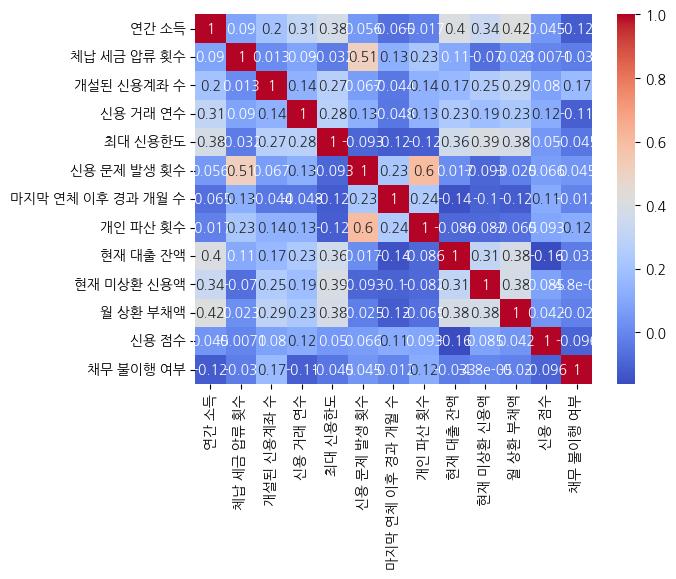

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

n_train= train_df.copy()
numeric_n_train = n_train.select_dtypes(include=np.number)

corr_matrix = numeric_n_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


<h1>Pre-Precessing</h1>

In [34]:
categorical_col = [
    '주거 형태',
    '대출 목적',
    '대출 상환 기간'
]

#OneHotEncoder 초기화
encoder = OneHotEncoder(sparse_output=False, handle_unknown = 'ignore')

#훈련데이터에 대한 인코더 학습

encoder.fit(train_df[categorical_col])

train_encoded = encoder.transform(train_df[categorical_col])
test_encoded = encoder.transform(test_df[categorical_col])

# One-hot encoding 결과를 데이터프레임으로 변환
train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(categorical_col))
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(categorical_col))

# 인코딩된 결과를 원래 데이터에 적용
train_df = pd.concat([train_df.drop(columns=categorical_col).reset_index(drop=True), train_encoded_df], axis=1)
test_df = pd.concat([test_df.drop(columns=categorical_col).reset_index(drop=True), test_encoded_df], axis=1)

In [35]:
# 변환할 매핑 딕셔너리 생성
income_mapping = {
    "1년 미만": 0,"1년": 1, "2년": 2, "3년": 3, "4년": 4, "5년": 5,
    "6년": 6, "7년": 7, "8년": 8, "9년": 9, "10년": 10,
    "10년 이상": 11  # '10년 이상'을 15로 변환
}

# "현재직장근속연수" 컬럼 변환
train_df["현재 직장 근속 연수"] = train_df["현재 직장 근속 연수"].replace(income_mapping).astype(int)
test_df["현재 직장 근속 연수"] = test_df["현재 직장 근속 연수"].replace(income_mapping).astype(int)

In [36]:
m_train = train_df.copy()
m_train['총 신용 사용량'] = m_train['신용 거래 연수'] * m_train['개설된 신용계좌 수']
m_train['총 부채'] = m_train['현재 대출 잔액'] + m_train['현재 미상환 신용액']
m_train['dsr'] = m_train['총 부채'] / m_train['연간 소득']
m_train['신용한도 대비 사용 비율'] = m_train['현재 미상환 신용액'] / m_train['최대 신용한도']
m_train = m_train.drop(columns = ['월 상환 부채액', '현재 대출 잔액', '현재 미상환 신용액', '신용 거래 연수', '개설된 신용계좌 수'])

In [37]:
train_df = m_train

In [38]:
test_df['총 신용 사용량'] = train_df['총 신용 사용량']
test_df['총 부채'] = train_df['총 부채']
test_df['dsr'] = train_df['dsr']
test_df['신용한도 대비 사용 비율'] = train_df['신용한도 대비 사용 비율']
test_df = test_df.drop(columns = ['월 상환 부채액', '현재 대출 잔액', '현재 미상환 신용액', '신용 거래 연수', '개설된 신용계좌 수'])

In [13]:
n_train = train_df.copy()
n_train['대출액'] = (n_train['월 상환 부채액']*12 + n_train['현재 대출 잔액'] + n_train['현재 미상환 신용액'])/3
n_train = n_train.drop(columns = ['현재 대출 잔액', '현재 미상환 신용액'])

In [14]:
not_need = ['대출 목적_결혼 자금',
           '대출 목적_고액 구매',
           '대출 목적_기타',
           '대출 목적_소규모 사업 자금',
           '대출 목적_여행 자금',
           '대출 목적_이사 비용',
           '대출 목적_자동차 구매',
           '대출 목적_주택 개보수',
           '대출 목적_휴가 비용'
            ]

need = ['대출 목적_교육비', '대출 목적_사업 대출',
        '대출 목적_주택 구매','대출 목적_부채 통합'
        '대출 목적_의료비'
        ]
n_train['사치'] = n_train[not_need].sum(axis = 1)
n_train['필수'] = n_train[need].sum(axis = 1)
n_train = n_train.drop(columns = not_need + need)

KeyError: "None of [Index(['대출 목적_결혼 자금', '대출 목적_고액 구매', '대출 목적_기타', '대출 목적_소규모 사업 자금',\n       '대출 목적_여행 자금', '대출 목적_이사 비용', '대출 목적_자동차 구매', '대출 목적_주택 개보수',\n       '대출 목적_휴가 비용'],\n      dtype='object')] are in the [columns]"

In [ ]:
n_train['dsr'] = n_train['월 상환 부채액'] / (n_train['연간 소득'] / 12)
n_train = n_train.drop(columns = ['월 상환 부채액'])
n_train['문제'] = n_train[['신용 문제 발생 횟수', '개인 파산 횟수', '체납 세금 압류 횟수']].mean(axis=1)
n_train = n_train.drop(columns = ['신용 문제 발생 횟수', '개인 파산 횟수', '체납 세금 압류 횟수'])

In [ ]:
train_df = n_train

In [ ]:
test_df['대출액'] = train_df['대출액']
#test_df['사치'] = train_df['사치']
#test_df['필수'] = train_df['필수']
test_df['dsr'] = train_df['dsr']
test_df['문제'] = train_df['문제']
#test_df = test_df.drop(columns = ['월 상환 부채액', '현재 대출 잔액', '현재 미상환 신용액'] + not_need + need)
test_df = test_df.drop(columns = ['월 상환 부채액', '현재 대출 잔액', '현재 미상환 신용액'])

<h1>Train Data Split</h1>

In [ ]:
import sklearn
import xgboost

In [ ]:
'''
#Train dataset 만 X_train, X_Val로 다시 구분
X_train, X_val, y_train, y_val = train_test_split(
    train_df.drop(columns=['채무 불이행 여부']),
    train_df['채무 불이행 여부'],
    test_size=0.2,
    random_state=42
)
'''

In [ ]:
'''
min_max scaled dataframe normalized_data
'''
X_train, X_val, y_train, y_val = train_test_split(
    normalized_df,
    train_df['채무 불이행 여부'],
    test_size=0.2,
    random_state=42
)

<h1>모델 학습(XGBoost)-minmax_scaled</h1>

In [ ]:
model = XGBClassifier(
    n_estimators =100,
    max_depth = 6,
    learning_rate = 0.15,
    random_state=42,
    eval_metric="auc",
)

In [ ]:
eval_set = [(X_train,y_train),(X_val,y_val)]
model.fit(
    X_train, y_train,
    eval_set = eval_set,
    verbose = True
    )

[0]	validation_0-auc:0.74804	validation_1-auc:0.67600
[1]	validation_0-auc:0.76282	validation_1-auc:0.68738
[2]	validation_0-auc:0.77939	validation_1-auc:0.70043
[3]	validation_0-auc:0.78533	validation_1-auc:0.70372
[4]	validation_0-auc:0.79109	validation_1-auc:0.70516
[5]	validation_0-auc:0.79493	validation_1-auc:0.70674
[6]	validation_0-auc:0.80176	validation_1-auc:0.70570
[7]	validation_0-auc:0.80667	validation_1-auc:0.70844
[8]	validation_0-auc:0.81299	validation_1-auc:0.70870
[9]	validation_0-auc:0.81639	validation_1-auc:0.70862
[10]	validation_0-auc:0.82119	validation_1-auc:0.70940
[11]	validation_0-auc:0.82549	validation_1-auc:0.71025
[12]	validation_0-auc:0.82950	validation_1-auc:0.71064
[13]	validation_0-auc:0.83201	validation_1-auc:0.71078
[14]	validation_0-auc:0.83521	validation_1-auc:0.71063
[15]	validation_0-auc:0.83802	validation_1-auc:0.70987
[16]	validation_0-auc:0.84052	validation_1-auc:0.71156
[17]	validation_0-auc:0.84336	validation_1-auc:0.71081
[18]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
eval_set = [(X_train,y_train),(X_val,y_val)]
model.fit(
    normalized_df, train_df['채무 불이행 여부'],
    eval_set = eval_set,
    verbose = True
    )

[0]	validation_0-auc:0.74200	validation_1-auc:0.73347
[1]	validation_0-auc:0.75705	validation_1-auc:0.74860
[2]	validation_0-auc:0.77022	validation_1-auc:0.75861
[3]	validation_0-auc:0.77557	validation_1-auc:0.76240
[4]	validation_0-auc:0.78330	validation_1-auc:0.77184
[5]	validation_0-auc:0.78663	validation_1-auc:0.77630
[6]	validation_0-auc:0.79045	validation_1-auc:0.78059
[7]	validation_0-auc:0.79680	validation_1-auc:0.78613
[8]	validation_0-auc:0.80026	validation_1-auc:0.78905
[9]	validation_0-auc:0.80395	validation_1-auc:0.79338
[10]	validation_0-auc:0.80870	validation_1-auc:0.79648
[11]	validation_0-auc:0.81133	validation_1-auc:0.79915
[12]	validation_0-auc:0.81478	validation_1-auc:0.80246
[13]	validation_0-auc:0.81783	validation_1-auc:0.80419
[14]	validation_0-auc:0.82047	validation_1-auc:0.80662
[15]	validation_0-auc:0.82465	validation_1-auc:0.81113
[16]	validation_0-auc:0.82727	validation_1-auc:0.81388
[17]	validation_0-auc:0.82822	validation_1-auc:0.81570
[18]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

<h1>Prediction&Submission</h1>

In [ ]:
# 채무 불이행 '확률'을 예측합니다.
preds = model.predict_proba(test_normalized_df)[:,1]
print(preds)

[0.24255665 0.21681306 0.7344386  ... 0.39845645 0.1778733  0.03255113]


In [ ]:
submit = pd.read_csv('./채무불이행/sample_submission.csv')
num_rows_submit = submit.shape[0]
# 결과 저장
submit['채무 불이행 확률'] = preds[:num_rows_submit]
submit.to_csv('./채무불이행/submission.csv', encoding='UTF-8-sig', index=False)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

<h1>스케일링</h1>

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_X = train_df.drop(columns = ['채무 불이행 여부'])
original_columns = train_X.columns
# 각 컬럼별로 정규화
normalized_data = scaler.fit_transform(train_X)  # df는 원본 DataFrame
normalized_df = pd.DataFrame(normalized_data, columns = original_columns)


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [ ]:
og_columns_test = test_df.columns
test_data = scaler.transform(train_X)
test_normalized_df = pd.DataFrame(test_data, columns=og_columns_test)

ValueError: Shape of passed values is (10000, 19), indices imply (10000, 22)